In [89]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import loadmat


In [90]:
#cargar archivo .mat
data= loadmat('signals.mat')

#mostrar las variables que contienen el archivo
print(data.keys())

dict_keys(['__header__', '__version__', '__globals__', 'Fs', 'ECG_asRecording', 'ECG_filtered', 'EMG_filtered1', 'EMG_filtered2', 'EMG_asRecording1', 'EMG_asRecording2'])


In [91]:
#Extraer la señal original  (sin filtrar)
recording = data['ECG_asRecording']

#Extraer la señal filtrada
filtered = data['ECG_filtered']


In [92]:
def calcular_rms(signal):

  rms = np.sqrt(np.mean(signal**2))

  return rms

In [93]:
#Calcular RMS de la señal original
rms_recording = calcular_rms(recording)
rms_filtered = calcular_rms(filtered)

#Mostrar resultados
print("RMS Señal original: ", rms_recording)
print("RMS Señal filtrada: ", rms_filtered)

RMS Señal original:  4392.9682937490725
RMS Señal filtrada:  286.30557115249496


In [94]:
recording = recording.flatten()
filtered = filtered.flatten()


print(recording.shape)

(30720,)


In [95]:
fs = 1024   # frecuencia de muestreo

N = len(recording)   # número de muestras

t = np.arange(N) / fs   # vector de tiempo

print("t shape:", t.shape)
print("Número de muestras:", N)

t shape: (30720,)
Número de muestras: 30720


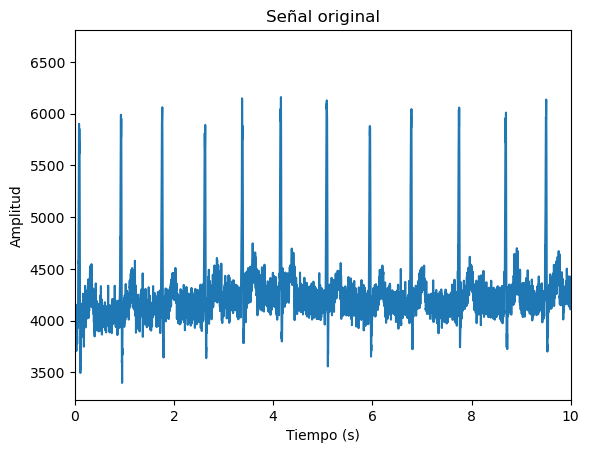

In [96]:
# Señal original
plt.figure()
plt.plot(t, recording)
plt.title("Señal original")
plt.xlabel("Tiempo (s)")
plt.ylabel("Amplitud")
plt.xlim(0, 10)  # Mostrar solo los primeros 10 segundos
plt.show()


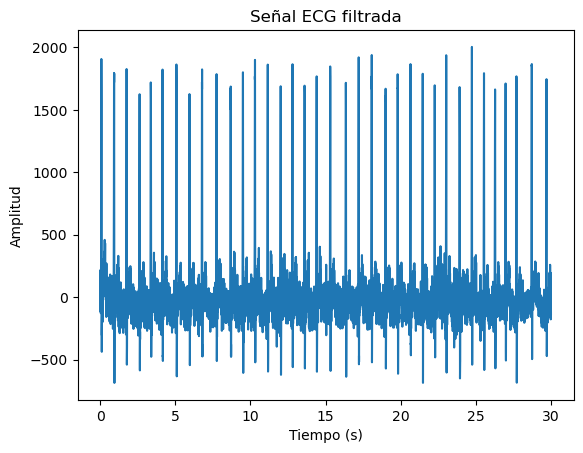

In [97]:
# Señal filtrada
plt.figure()

plt.plot(t, filtered)

plt.title("Señal ECG filtrada")
plt.xlabel("Tiempo (s)")
plt.ylabel("Amplitud")

plt.show()

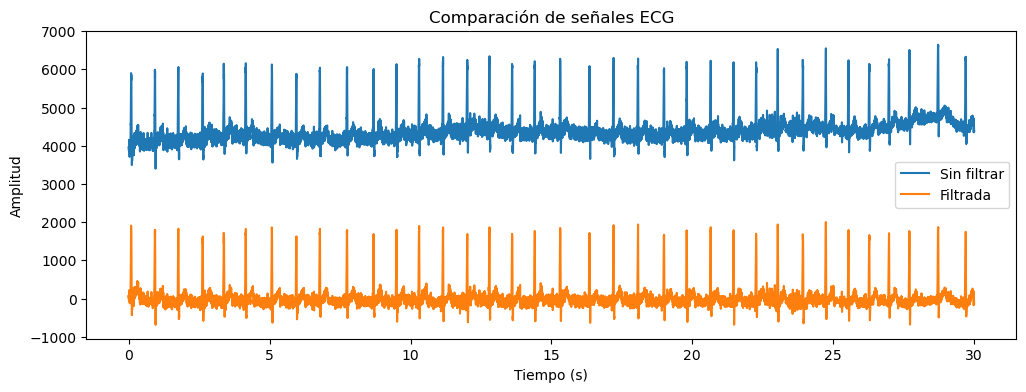

In [98]:
# Comparación de señales
plt.figure(figsize=(12,4))

plt.plot(t, recording, label="Sin filtrar")
plt.plot(t, filtered, label="Filtrada")

plt.title("Comparación de señales ECG")
plt.xlabel("Tiempo (s)")
plt.ylabel("Amplitud")

plt.legend()
plt.show()

Al comparar la señal ECG sin filtrar con la señal filtrada, se observa que la señal original presenta mayor ruido y variaciones en la línea base. A pesar de esto, se pueden identificar los picos correspondientes a los complejos QRS, característicos de la actividad eléctrica del corazón.

Después del filtrado, la señal muestra menor ruido y una línea base más estable, lo que permite visualizar con mayor claridad los complejos QRS y la morfología general del ECG. Esto indica que el filtro elimina componentes de ruido sin afectar significativamente la información fisiológica de la señal.

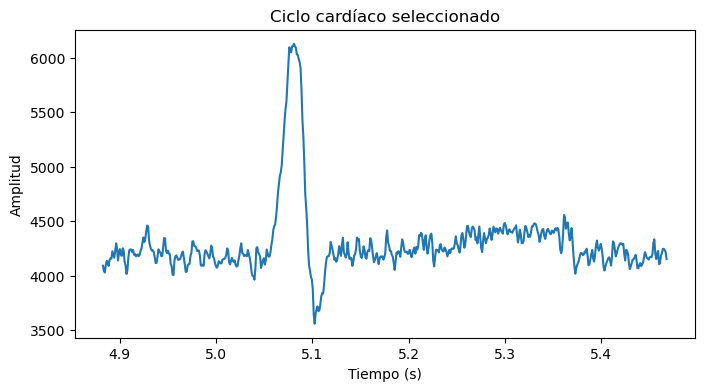

In [99]:
inicio = 5000 # punto de inicio del ciclo cardíaco
fin = 5600 # punto de fin del ciclo cardíaco (ajustar según la duración del ciclo)

ciclo = recording[inicio:fin] # extraer el ciclo cardíaco de la señal original
t_ciclo = t[inicio:fin]

plt.figure(figsize=(8,4))
plt.plot(t_ciclo, ciclo)

plt.title("Ciclo cardíaco seleccionado")
plt.xlabel("Tiempo (s)")
plt.ylabel("Amplitud")

plt.show()

In [101]:
media = np.mean(ciclo)
varianza = np.var(ciclo)
desviacion = np.std(ciclo)
rms = calcular_rms(ciclo)


print("Promedio:", media)
print("RMS:", rms)
print("Varianza:", varianza)
print("Desviación estándar:", desviacion)

Promedio: 4296.742410888672
RMS: 4310.518937991141
Varianza: 118578.16925087877
Desviación estándar: 344.35181029127574
